# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [189]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [190]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [191]:
#Variaveis de controle
anotado = 300
# num_replys_anotados = 150
# num_quotes_anotados = 150
# num_originals_anotados = 150

In [192]:
# baixando dataset para o collab
import gdown

file_class_caio = "1ckE4_CHo6h4-2RuHOovi7oFxqUZ6_YIw"
file_class_victor = "1FamALJBfOegb407zpCKWuclX7v6nl_sG"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "mandetta_anotado_caio.csv", quiet=False)
gdown.download(url_2, "mandetta_anotado_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ckE4_CHo6h4-2RuHOovi7oFxqUZ6_YIw
To: /content/mandetta_anotado_caio.csv
100%|██████████| 11.1M/11.1M [00:00<00:00, 197MB/s]
Downloading...
From: https://drive.google.com/uc?id=1FamALJBfOegb407zpCKWuclX7v6nl_sG
To: /content/mandetta_anotado_victor.csv
100%|██████████| 11.1M/11.1M [00:00<00:00, 225MB/s]


'mandetta_anotado_victor.csv'

In [193]:
#carregando o dataset
df_caio = pd.read_csv ("mandetta_anotado_caio.csv")
df_victor = pd.read_csv ("mandetta_anotado_victor.csv")

In [194]:
#numero total de instancias no dataset
df_caio.shape

(36429, 6)

In [195]:
#numero total de instancias no dataset
df_victor.shape

(36429, 6)

In [196]:
df_caio.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,"""E o Mandetta, a linha dele, como médico, era ...","Tá certo, tem que demitir um ministro da SAÚDE...",2,0.044222,0.955778,0.0
1,Acabo de ouvir do presidente Jair Bolsonaro o ...,O privatizador e lobista dos planos de saúde f...,2,0.049353,0.950647,1.0
2,"Boa sorte ao Nelson Teich, novo ministro da Sa...","Fala verdade seu safado, vc torce pro quanto p...",1,0.050033,0.949967,1.0
3,"É preciso reconhecer que se não fosse o SUS, n...",Esse mesmo SUS que o Mandetta defendeu o fim e...,2,0.070362,0.929638,0.0
4,"""E o Mandetta, a linha dele, como médico, era ...",onde já se viu um médico preocupado com a vida ?,2,0.078197,0.921803,0.0
5,Caminhamos para o abismo! Tirar é urgente par...,"Fernanda, o Bolsonaro está preservando vida, e...",2,0.085222,0.914778,1.0
6,“não vou mais me estressar com as merdas que e...,Não tem como não se estressar com oq ele faz q...,2,0.086673,0.913327,0.0
7,"Na moral gente, tudo bem criticar o Bolsonaro ...",o foco princípal do cara era o desmonte do SUS...,1,0.086982,0.913018,0.0
8,Ai vou morrer pq o Mandetta saiu!!! Vai te fo...,Não seja inocente meu caro. Você sabe muito be...,1,0.095434,0.904567,1.0
9,A maioria esmagadora dos brasileiros é contrár...,"Senador, não se queime por uma MERDA como MAND...",1,0.105065,0.894935,1.0


In [197]:
df_victor.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,"""E o Mandetta, a linha dele, como médico, era ...","Tá certo, tem que demitir um ministro da SAÚDE...",2,0.044222,0.955778,0.0
1,Acabo de ouvir do presidente Jair Bolsonaro o ...,O privatizador e lobista dos planos de saúde f...,2,0.049353,0.950647,1.0
2,"Boa sorte ao Nelson Teich, novo ministro da Sa...","Fala verdade seu safado, vc torce pro quanto p...",1,0.050033,0.949967,1.0
3,"É preciso reconhecer que se não fosse o SUS, n...",Esse mesmo SUS que o Mandetta defendeu o fim e...,2,0.070362,0.929638,0.0
4,"""E o Mandetta, a linha dele, como médico, era ...",onde já se viu um médico preocupado com a vida ?,2,0.078197,0.921803,0.0
5,Caminhamos para o abismo! Tirar é urgente par...,"Fernanda, o Bolsonaro está preservando vida, e...",2,0.085222,0.914778,1.0
6,“não vou mais me estressar com as merdas que e...,Não tem como não se estressar com oq ele faz q...,2,0.086673,0.913327,0.0
7,"Na moral gente, tudo bem criticar o Bolsonaro ...",o foco princípal do cara era o desmonte do SUS...,1,0.086982,0.913018,0.0
8,Ai vou morrer pq o Mandetta saiu!!! Vai te fo...,Não seja inocente meu caro. Você sabe muito be...,1,0.095434,0.904567,1.0
9,A maioria esmagadora dos brasileiros é contrár...,"Senador, não se queime por uma MERDA como MAND...",1,0.105065,0.894935,1.0


# **Analise Exploratória**



In [198]:
# restrigindo por quantidade anotada
df_caio = df_caio.iloc[:anotado,:]
df_caio['Conflict'] = df_caio['Conflict'].astype(int) #convertendo valores para inteiros
df_victor = df_victor.iloc[:anotado,:]
df_victor['Conflict'] = df_victor['Conflict'].astype(int)

In [199]:
#separando por classe

In [200]:
df_caio

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,"""E o Mandetta, a linha dele, como médico, era ...","Tá certo, tem que demitir um ministro da SAÚDE...",2,0.044222,0.955778,0
1,Acabo de ouvir do presidente Jair Bolsonaro o ...,O privatizador e lobista dos planos de saúde f...,2,0.049353,0.950647,1
2,"Boa sorte ao Nelson Teich, novo ministro da Sa...","Fala verdade seu safado, vc torce pro quanto p...",1,0.050033,0.949967,1
3,"É preciso reconhecer que se não fosse o SUS, n...",Esse mesmo SUS que o Mandetta defendeu o fim e...,2,0.070362,0.929638,0
4,"""E o Mandetta, a linha dele, como médico, era ...",onde já se viu um médico preocupado com a vida ?,2,0.078197,0.921803,0
...,...,...,...,...,...,...
295,"""E o Mandetta, a linha dele, como médico, era ...","Aiai, esses médicos irresponsáveis que se preo...",2,0.055106,0.944894,0
296,Bolsonaro demitiu o Mandetta. Vai ficar pra Hi...,"e além do mais, o que um oncologista tem haver...",2,0.055110,0.944890,0
297,"""E o Mandetta, a linha dele, como médico, era ...",o cara é médico e você acha que ele vai priori...,2,0.055252,0.944748,0
298,"""E o Mandetta, a linha dele, como médico, era ...",a vida não é importante? seu merda,2,0.055350,0.944650,0


In [201]:
df_victor

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,"""E o Mandetta, a linha dele, como médico, era ...","Tá certo, tem que demitir um ministro da SAÚDE...",2,0.044222,0.955778,0
1,Acabo de ouvir do presidente Jair Bolsonaro o ...,O privatizador e lobista dos planos de saúde f...,2,0.049353,0.950647,1
2,"Boa sorte ao Nelson Teich, novo ministro da Sa...","Fala verdade seu safado, vc torce pro quanto p...",1,0.050033,0.949967,1
3,"É preciso reconhecer que se não fosse o SUS, n...",Esse mesmo SUS que o Mandetta defendeu o fim e...,2,0.070362,0.929638,0
4,"""E o Mandetta, a linha dele, como médico, era ...",onde já se viu um médico preocupado com a vida ?,2,0.078197,0.921803,0
...,...,...,...,...,...,...
295,"""E o Mandetta, a linha dele, como médico, era ...","Aiai, esses médicos irresponsáveis que se preo...",2,0.055106,0.944894,0
296,Bolsonaro demitiu o Mandetta. Vai ficar pra Hi...,"e além do mais, o que um oncologista tem haver...",2,0.055110,0.944890,0
297,"""E o Mandetta, a linha dele, como médico, era ...",o cara é médico e você acha que ele vai priori...,2,0.055252,0.944748,0
298,"""E o Mandetta, a linha dele, como médico, era ...",a vida não é importante? seu merda,2,0.055350,0.944650,0


In [202]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem

In [203]:
for i in range(df_caio.shape[0]):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [204]:
confusion

array([[168.,   7.,   2.],
       [ 10., 104.,   2.],
       [  4.,   3.,   0.]])

In [205]:
idx_diff

[11,
 14,
 21,
 46,
 54,
 61,
 84,
 91,
 96,
 99,
 120,
 129,
 130,
 133,
 148,
 152,
 156,
 159,
 160,
 173,
 178,
 192,
 224,
 247,
 264,
 271,
 279,
 291]

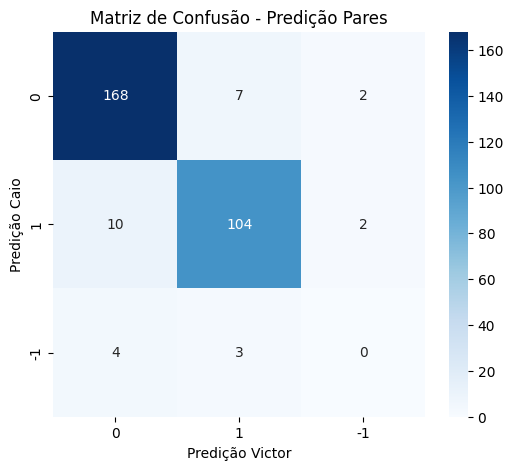

In [206]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares")
plt.show()

In [207]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}
mapa_tipo = {0: "Genérico", 1: "Reply", 2: "Quote"}

for i in range(len(idx_diff)):
  print("Tipo: ", mapa_tipo[int(df_caio.loc[idx_diff[i], "Class"])])
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tipo:  Reply
Tweet 1:  A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados discordam do afastamento do ministro da Saúde, segundo pesquisa realizada pelo Atlas Político. Vc concorda com o resultado da pesquisa?   via
Tweet 2:  Pesquisa q vc acredita, o povo brasileiro não, já vai tarde mandetta pau mandado
Classificação Caio:  Conflito
Classificação Victor:  Não Conflito

Tipo:  Quote
Tweet 1:  Acabo de ouvir do presidente Jair Bolsonaro o aviso da minha demissão do Ministério da Saúde.  Quero agradecer a oportunidade que me foi dada, de ser gerente do nosso SUS, de pôr de pé o projeto de melhoria da saúde dos brasileiros e
Tweet 2:  Obrigada Mandetta, vc tá realizado agora, eu nemsabiq da sua existência antes de vc ser ministro, vá com Deus
Classificação Caio:  Conflito
Classificação Victor:  Indeterminado

Tipo:  Reply
Tweet 1:  A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados discordam do af

In [208]:
#CLASSIFICAÇÕES POR CLASSES CAIO
print("CLASSIFICAÇÕES POR CLASSES CAIO:")
print("mandetta:")
print("Conflito:", df_caio[df_caio['Conflict'] == 1].shape[0])
print("Não conflito:", df_caio[df_caio['Conflict'] == 0].shape[0])
print("Indeterminado:", df_caio[df_caio['Conflict'] == -1].shape[0])

CLASSIFICAÇÕES POR CLASSES CAIO:
mandetta:
Conflito: 116
Não conflito: 177
Indeterminado: 7


In [209]:
#CLASSIFICAÇÕES POR CLASSES VICTOR
print("CLASSIFICAÇÕES POR CLASSES VICTOR:")
print("mandetta:")
print("Conflito:", df_victor[df_victor['Conflict'] == 1].shape[0])
print("Não conflito:", df_victor[df_victor['Conflict'] == 0].shape[0])
print("Indeterminado:", df_victor[df_victor['Conflict'] == -1].shape[0])

CLASSIFICAÇÕES POR CLASSES VICTOR:
mandetta:
Conflito: 114
Não conflito: 182
Indeterminado: 4


In [210]:
#Distribuição de conflitos por classes CAIO

#Separando as classes
reply_caio = df_caio[df_caio['Class'] == 1]
quote_caio = df_caio[df_caio['Class'] == 2]
original_caio = df_caio[df_caio['Class'] == 0]
print("Distribuição de conflitos por classes CAIO:")
print("Replys anotados:", reply_caio.shape[0])
print("Conflitos:", reply_caio[reply_caio['Conflict'] == 1].shape[0])
print("Não conflitos:", reply_caio[reply_caio['Conflict'] == 0].shape[0])
print()
print("Quote anotados:", quote_caio.shape[0])
print("Conflitos:", quote_caio[quote_caio['Conflict'] == 1].shape[0])
print("Não conflitos:", quote_caio[quote_caio['Conflict'] == 0].shape[0])
print()
print("Originals anotados:", original_caio.shape[0])
print("Conflitos:", original_caio[original_caio['Conflict'] == 1].shape[0])
print("Não conflitos:", original_caio[original_caio['Conflict'] == 0].shape[0])

Distribuição de conflitos por classes CAIO:
Replys anotados: 114
Conflitos: 63
Não conflitos: 49

Quote anotados: 145
Conflitos: 47
Não conflitos: 93

Originals anotados: 41
Conflitos: 6
Não conflitos: 35


In [211]:
#Distribuição de conflitos por classes VICTOR

#Separando as classes
reply_victor = df_victor[df_victor['Class'] == 1]
quote_victor = df_victor[df_victor['Class'] == 2]
original_victor = df_victor[df_victor['Class'] == 0]
print("Distribuição de conflitos por classes VICTOR:")
print("Replys anotados:", reply_victor.shape[0])
print("Conflitos:", reply_victor[reply_victor['Conflict'] == 1].shape[0])
print("Não conflitos:", reply_victor[reply_victor['Conflict'] == 0].shape[0])
print()
print("Quote anotados:", quote_victor.shape[0])
print("Conflitos:", quote_victor[quote_victor['Conflict'] == 1].shape[0])
print("Não conflitos:", quote_victor[quote_victor['Conflict'] == 0].shape[0])
print()
print("Originals anotados:", original_victor.shape[0])
print("Conflitos:", original_victor[original_victor['Conflict'] == 1].shape[0])
print("Não conflitos:", original_victor[original_victor['Conflict'] == 0].shape[0])

Distribuição de conflitos por classes VICTOR:
Replys anotados: 114
Conflitos: 59
Não conflitos: 53

Quote anotados: 145
Conflitos: 47
Não conflitos: 96

Originals anotados: 41
Conflitos: 8
Não conflitos: 33


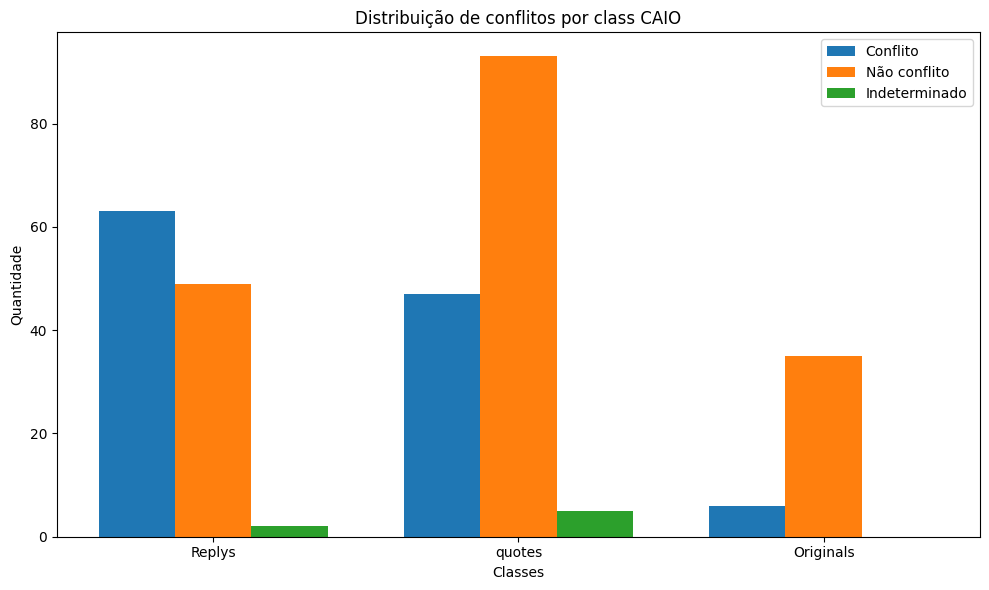

In [212]:
# grafico
# Registando as contagens de classificações por estruturas
classes = ['Replys', 'quotes', 'Originals']

conflitos = [
    reply_caio[reply_caio['Conflict'] == 1].shape[0],
    quote_caio[quote_caio['Conflict'] == 1].shape[0],
    original_caio[original_caio['Conflict'] == 1].shape[0]
]

nao_conflitos = [
    reply_caio[reply_caio['Conflict'] == 0].shape[0],
    quote_caio[quote_caio['Conflict'] == 0].shape[0],
    original_caio[original_caio['Conflict'] == 0].shape[0]
]

indeterminados = [
    reply_caio[reply_caio['Conflict'] == -1].shape[0],
    quote_caio[quote_caio['Conflict'] == -1].shape[0],
    original_caio[original_caio['Conflict'] == -1].shape[0]
]



# Posição das barras

x = np.arange(len(classes))

largura = 0.25

#desenhando o grafico

plt.figure(figsize=(10,6))

plt.bar(x - largura, conflitos,
        width=largura,
        label='Conflito')

plt.bar(x, nao_conflitos,
        width=largura,
        label='Não conflito')

plt.bar(x + largura, indeterminados,
        width=largura,
        label='Indeterminado')

plt.xticks(x, classes)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.title("Distribuição de conflitos por class CAIO")

plt.legend()

plt.tight_layout()

plt.show()

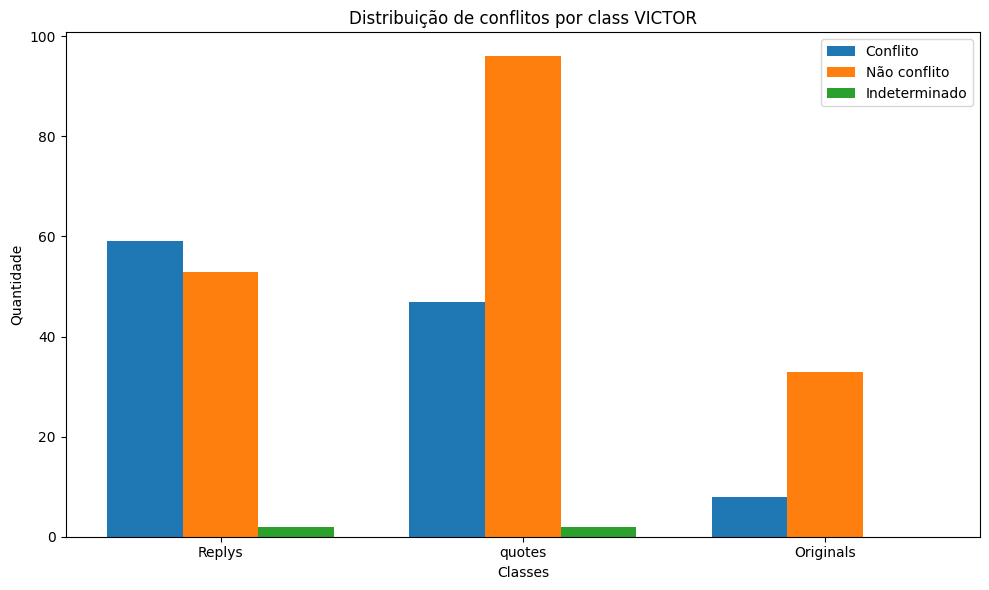

In [213]:
# grafico
# Registando as contagens de classificações por estruturas
classes = ['Replys', 'quotes', 'Originals']

conflitos = [
    reply_victor[reply_victor['Conflict'] == 1].shape[0],
    quote_victor[quote_victor['Conflict'] == 1].shape[0],
    original_victor[original_victor['Conflict'] == 1].shape[0]
]

nao_conflitos = [
    reply_victor[reply_victor['Conflict'] == 0].shape[0],
    quote_victor[quote_victor['Conflict'] == 0].shape[0],
    original_victor[original_victor['Conflict'] == 0].shape[0]
]

indeterminados = [
    reply_victor[reply_victor['Conflict'] == -1].shape[0],
    quote_victor[quote_victor['Conflict'] == -1].shape[0],
    original_victor[original_victor['Conflict'] == -1].shape[0]
]



# Posição das barras

x = np.arange(len(classes))

largura = 0.25

#desenhando o grafico

plt.figure(figsize=(10,6))

plt.bar(x - largura, conflitos,
        width=largura,
        label='Conflito')

plt.bar(x, nao_conflitos,
        width=largura,
        label='Não conflito')

plt.bar(x + largura, indeterminados,
        width=largura,
        label='Indeterminado')

plt.xticks(x, classes)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.title("Distribuição de conflitos por class VICTOR")

plt.legend()

plt.tight_layout()

plt.show()

In [214]:
# Previsoes incorretas CAIO:
df_inc_caio = df_caio[(df_caio['P(Conflict)'] > 0.5) & (df_caio['Conflict'] != 1)]
df_inc_caio.shape

(76, 6)

In [215]:
# Previsoes incorretas VICTOR:
df_inc_victor = df_victor[(df_victor['P(Conflict)'] > 0.5) & (df_victor['Conflict'] != 1)]
df_inc_victor.shape

(83, 6)

In [216]:
#Erros por classe de tweet CAIO
print("Erros por classe de tweet:")
print("Replys:", df_inc_caio[df_inc_caio['Class'] == 1].shape[0])
print("Quotes:", df_inc_caio[df_inc_caio['Class'] == 2].shape[0])
print("Originals:", df_inc_caio[df_inc_caio['Class'] == 0].shape[0])

Erros por classe de tweet:
Replys: 13
Quotes: 61
Originals: 2


In [217]:
#Erros por classe de tweet VICTOR
print("Erros por classe de tweet:")
print("Replys:", df_inc_victor[df_inc_victor['Class'] == 1].shape[0])
print("Quotes:", df_inc_victor[df_inc_victor['Class'] == 2].shape[0])
print("Originals:", df_inc_victor[df_inc_victor['Class'] == 0].shape[0])

Erros por classe de tweet:
Replys: 18
Quotes: 63
Originals: 2


In [218]:
#Organizando classificações de conflitos de Caio e Victor em um unico DF
df = df_caio.drop('Conflict', axis = 1)
df['Conflict_Caio'] = df_caio['Conflict']
df['Conflict_Victor'] = df_victor['Conflict']

In [219]:
df

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict_Caio,Conflict_Victor
0,"""E o Mandetta, a linha dele, como médico, era ...","Tá certo, tem que demitir um ministro da SAÚDE...",2,0.044222,0.955778,0,0
1,Acabo de ouvir do presidente Jair Bolsonaro o ...,O privatizador e lobista dos planos de saúde f...,2,0.049353,0.950647,1,1
2,"Boa sorte ao Nelson Teich, novo ministro da Sa...","Fala verdade seu safado, vc torce pro quanto p...",1,0.050033,0.949967,1,1
3,"É preciso reconhecer que se não fosse o SUS, n...",Esse mesmo SUS que o Mandetta defendeu o fim e...,2,0.070362,0.929638,0,0
4,"""E o Mandetta, a linha dele, como médico, era ...",onde já se viu um médico preocupado com a vida ?,2,0.078197,0.921803,0,0
...,...,...,...,...,...,...,...
295,"""E o Mandetta, a linha dele, como médico, era ...","Aiai, esses médicos irresponsáveis que se preo...",2,0.055106,0.944894,0,0
296,Bolsonaro demitiu o Mandetta. Vai ficar pra Hi...,"e além do mais, o que um oncologista tem haver...",2,0.055110,0.944890,0,0
297,"""E o Mandetta, a linha dele, como médico, era ...",o cara é médico e você acha que ele vai priori...,2,0.055252,0.944748,0,0
298,"""E o Mandetta, a linha dele, como médico, era ...",a vida não é importante? seu merda,2,0.055350,0.944650,0,0


In [220]:
df.to_csv("mandetta_induzido_classificado.csv", index=False, encoding="utf-8")
files.download("mandetta_induzido_classificado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das divergencias**

In [221]:
div = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div['Conflict_caio'] = df_caio['Conflict'].iloc[idx_diff].astype(int)
div['Conflict_victor'] = df_victor['Conflict'].iloc[idx_diff].astype(int)
div['Conflict'] = np.nan

In [222]:
div.shape

(28, 8)

In [223]:
div

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict_caio,Conflict_victor,Conflict
11,A maioria esmagadora dos brasileiros é contrár...,"Pesquisa q vc acredita, o povo brasileiro não,...",1,0.112668,0.887331,1,0,NaN
14,Acabo de ouvir do presidente Jair Bolsonaro o ...,"Obrigada Mandetta, vc tá realizado agora, eu n...",2,0.118062,0.881938,1,-1,NaN
21,A maioria esmagadora dos brasileiros é contrár...,Óbvio que não Se 76% aprovam essa política de ...,1,0.233788,0.766212,1,0,NaN
46,"Em sua despedida, Mandetta defende a vida, o S...","é a isso que vocês querem se comparar, ô caral...",2,0.524996,0.475004,-1,1,NaN
54,A maioria esmagadora dos brasileiros é contrár...,Não levo em consideração qualquer pesquisa que...,1,0.571915,0.428085,1,0,NaN
61,“Jair conseguiu a proeza de transformar um pol...,"Na boa, tem gente que continua a saga da encer...",2,0.619237,0.380763,-1,0,NaN
84,"Em sua despedida, Mandetta defende a vida, o S...","Uma coisa sobre Mandetta, igualou-se a esquerd...",1,0.785604,0.214396,-1,1,NaN
91,"Em sua despedida, Mandetta defende a vida, o S...",Eu não tinha o que falar sobre o ministro Mand...,1,0.814333,0.185667,0,1,NaN
96,nao se esqueçam mandetta era um lobbysta de pl...,"Mandetta foi demitido, nem parece realidade is...",0,0.840318,0.159682,1,0,NaN
99,Desejo boa sorte ao agora ex-ministro Mandetta...,""" Que não se preocupe com a política eleitoral...",1,0.858742,0.141258,0,1,NaN


In [224]:
div_aborto_final = div.drop(columns=['Conflict_caio', 'Conflict_victor'])
div_aborto_final

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
11,A maioria esmagadora dos brasileiros é contrár...,"Pesquisa q vc acredita, o povo brasileiro não,...",1,0.112668,0.887331,NaN
14,Acabo de ouvir do presidente Jair Bolsonaro o ...,"Obrigada Mandetta, vc tá realizado agora, eu n...",2,0.118062,0.881938,NaN
21,A maioria esmagadora dos brasileiros é contrár...,Óbvio que não Se 76% aprovam essa política de ...,1,0.233788,0.766212,NaN
46,"Em sua despedida, Mandetta defende a vida, o S...","é a isso que vocês querem se comparar, ô caral...",2,0.524996,0.475004,NaN
54,A maioria esmagadora dos brasileiros é contrár...,Não levo em consideração qualquer pesquisa que...,1,0.571915,0.428085,NaN
61,“Jair conseguiu a proeza de transformar um pol...,"Na boa, tem gente que continua a saga da encer...",2,0.619237,0.380763,NaN
84,"Em sua despedida, Mandetta defende a vida, o S...","Uma coisa sobre Mandetta, igualou-se a esquerd...",1,0.785604,0.214396,NaN
91,"Em sua despedida, Mandetta defende a vida, o S...",Eu não tinha o que falar sobre o ministro Mand...,1,0.814333,0.185667,NaN
96,nao se esqueçam mandetta era um lobbysta de pl...,"Mandetta foi demitido, nem parece realidade is...",0,0.840318,0.159682,NaN
99,Desejo boa sorte ao agora ex-ministro Mandetta...,""" Que não se preocupe com a política eleitoral...",1,0.858742,0.141258,NaN


In [225]:
div_aborto_final.to_csv("divergencias_mandetta_induzido.csv", index=False, encoding="utf-8")
files.download("divergencias_mandetta_induzido.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das Convergencias**




In [226]:
conv_aborto = df_caio.drop(index=idx_diff, errors='ignore')
conv_aborto.shape

(272, 6)

In [227]:
conv_aborto

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,"""E o Mandetta, a linha dele, como médico, era ...","Tá certo, tem que demitir um ministro da SAÚDE...",2,0.044222,0.955778,0
1,Acabo de ouvir do presidente Jair Bolsonaro o ...,O privatizador e lobista dos planos de saúde f...,2,0.049353,0.950647,1
2,"Boa sorte ao Nelson Teich, novo ministro da Sa...","Fala verdade seu safado, vc torce pro quanto p...",1,0.050033,0.949967,1
3,"É preciso reconhecer que se não fosse o SUS, n...",Esse mesmo SUS que o Mandetta defendeu o fim e...,2,0.070362,0.929638,0
4,"""E o Mandetta, a linha dele, como médico, era ...",onde já se viu um médico preocupado com a vida ?,2,0.078197,0.921803,0
...,...,...,...,...,...,...
295,"""E o Mandetta, a linha dele, como médico, era ...","Aiai, esses médicos irresponsáveis que se preo...",2,0.055106,0.944894,0
296,Bolsonaro demitiu o Mandetta. Vai ficar pra Hi...,"e além do mais, o que um oncologista tem haver...",2,0.055110,0.944890,0
297,"""E o Mandetta, a linha dele, como médico, era ...",o cara é médico e você acha que ele vai priori...,2,0.055252,0.944748,0
298,"""E o Mandetta, a linha dele, como médico, era ...",a vida não é importante? seu merda,2,0.055350,0.944650,0


In [228]:
#juntando anotações do professor (QUANDO ELE ANOTAR)
#adicionando as classificações do professor
# file_class_prof = "1FSUrpSaiBAp5Gho-CsEw6kse3q4wCB8B"
# url = f"https://drive.google.com/uc?id={file_class_prof}"
# gdown.download(url, "class_prof.csv", quiet=False)
# df_class_prof = pd.read_csv ("class_prof.csv")

In [229]:
# df_class_prof

In [230]:
# df_desempate = div.iloc[:len(df_class_prof)-1,:]
# df_desempate

In [231]:
# df_desempate['Conflict_prof'] = df_class_prof['Conflict']
# df_desempate

In [232]:
# def resolver_conflito(row):
#     prof = row['Conflict_prof']
#     caio = row['Conflict_caio']
#     victor = row['Conflict_victor']

#     if prof == caio or prof == victor:
#         return prof
#     else:
#         return -1

# df_desempate['Conflict'] = df_desempate.apply(resolver_conflito, axis=1)

In [233]:
# df_desempate = df_desempate.drop(columns=['Conflict_caio', 'Conflict_victor', 'Conflict_prof'])
# df_desempate

In [234]:
# conv_aborto = pd.concat([conv_aborto, df_desempate], ignore_index=True, axis = 0)
# conv_aborto

In [235]:
conv_aborto.to_csv("convergencias_mandetta_induzido.csv", index=False, encoding="utf-8")
files.download("convergencias_mandetta_induzido.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>